# Cross-Validation: Bullinger0-2000

Evaluates models trained on the **READ ICFHR 2016** dataset (Ratsprotokolle, Bolzano, Kanzleikursive, 15th–19th c.)  \nagainst the **Bullinger0-2000** corpus (Zürich Reformation correspondence, humanistic secretary hand, 16th c.).\n\n**Research question:** How well do READ-fine-tuned models generalise to a same-language, different-collection, different-script dataset?\n\n| Model | Checkpoint | READ test CER | READ test WER |\n|---|---|---|---|\n| TrOCR (Base → READ) | `best_read_base/` | 6.18 % | 27.24 % |\n| Qwen3-VL-2B continued | `best_qwen_ft_read_continue/` | 19.96 % | 46.36 % |\n\n`best_qwen_ft_read_continue`: resumed from epoch-10 checkpoint, trained 10 more epochs (bfloat16, LR 2e-5, elastic distortion α=30 σ=4 p=0.5). Best val CER **16.48 %** at epoch 8 (200-sample subsample); full READ test set CER 19.96 %."

## Step 0 — Install
Dependencies are in `requirements.txt`. Install once from repo root:
```
pip install -r requirements.txt
```

## Step 1 — Imports & Paths

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import random
from pathlib import Path

import evaluate
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from jiwer import cer as line_cer
from PIL import Image
from tqdm.notebook import tqdm
from transformers import (
    AutoProcessor,
    Qwen3VLForConditionalGeneration,
    TrOCRProcessor,
    VisionEncoderDecoderModel,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

ROOT       = Path("..")
BULL_DIR   = ROOT / "data" / "Bullinger0-2000" / "de"
CKPT_ROOT  = ROOT / "checkpoints"
CKPT_TROCR = CKPT_ROOT / "best_read_base"
CKPT_QWEN  = CKPT_ROOT / "best_qwen_ft_read_continue"

MIN_PIXELS = 128 * 28 * 28
MAX_PIXELS = 512 * 28 * 28

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Bullinger dir: {BULL_DIR.resolve()}")
assert BULL_DIR.exists(),   f"Dataset not found: {BULL_DIR}"
assert CKPT_TROCR.exists(), f"TrOCR checkpoint missing: {CKPT_TROCR}"
assert CKPT_QWEN.exists(),  f"Qwen checkpoint missing: {CKPT_QWEN}"

Device: cuda
Bullinger dir: /home/justin/Ginger_Gradient/14/project/Capstone-Project/data/Bullinger0-2000/de


## Step 2 — Load Bullinger Dataset

In [2]:
records = []
for png in sorted(BULL_DIR.glob("*.png")):
    txt = png.with_suffix(".txt")
    if txt.exists():
        transcription = txt.read_text(encoding="utf-8").strip()
        if transcription:                    # skip empty
            records.append({"image_path": str(png), "transcription": transcription})

df = pd.DataFrame(records)
print(f"Lines loaded : {len(df)}")
print(f"Chars/line   : min={df['transcription'].str.len().min()}  "
      f"max={df['transcription'].str.len().max()}  "
      f"median={df['transcription'].str.len().median():.0f}")
df.head(5)

Lines loaded : 694
Chars/line   : min=3  max=97  median=49


,image_path,transcription
0,../data/Bullinger0-2000/de/1019_00_r1l14.png,Es were sein fürnemen im Obern Teutschland
1,../data/Bullinger0-2000/de/1027_01_r1l5.png,Basel.
2,../data/Bullinger0-2000/de/1030_01_r2l17.png,in dem truk außgon laßen; wirt bald harkhommen...
3,../data/Bullinger0-2000/de/1030_01_r2l18.png,Frieß ist eylendtz verritten; ist nie zuͦ mir ...
4,../data/Bullinger0-2000/de/1030_01_r2l9.png,"muͤssend all anhalten, damit wir in der eydgno..."


## Step 3 — Dataset Overview

/tmp/ipykernel_6881/2268766180.py:13: UserWarning: Glyph 117 (u) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/home/justin/Ginger_Gradient/14/project/Capstone-Project/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 117 (u) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


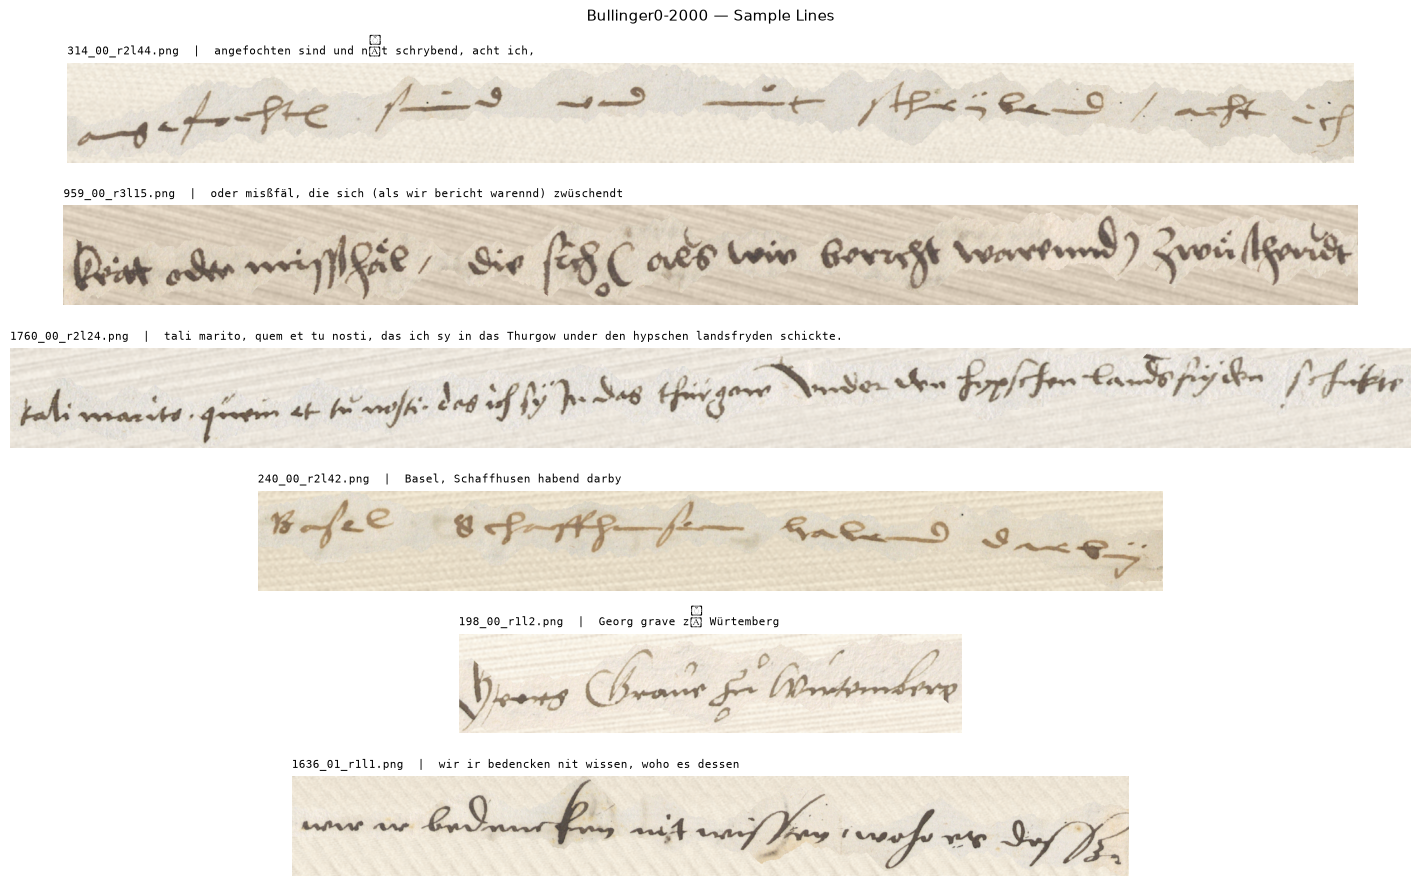

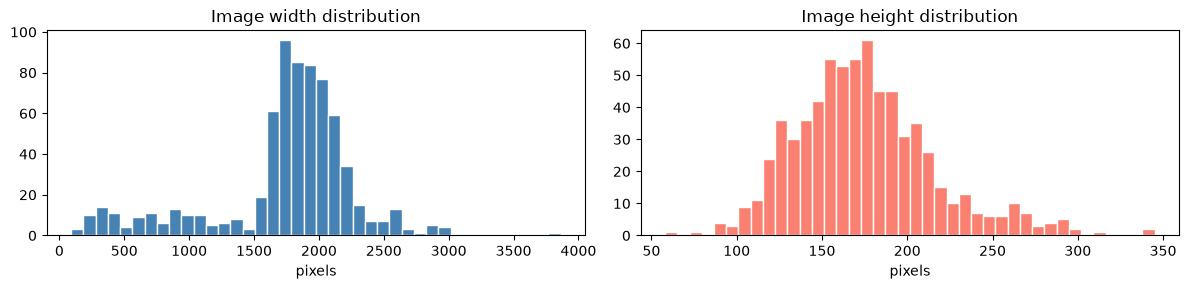


Image sizes — width:  median=1842 px
Image sizes — height: median=171 px
Unique characters (83): [' ', '!', '"', "'", '(', ')', '*', ',', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'Ö', 'Ü', 'ß', 'ä', 'ö', 'ü', 'ę', 'ͤ', 'ͦ']


In [3]:
# Sample images + ground truth
sample_idx = df.sample(6, random_state=SEED).index.tolist()

fig, axes = plt.subplots(6, 1, figsize=(16, 9))
for ax, idx in zip(axes, sample_idx):
    row = df.loc[idx]
    img = Image.open(row["image_path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"{Path(row['image_path']).name}  |  {row['transcription']}",
                 fontsize=8, loc="left", family="monospace")
    ax.axis("off")
plt.suptitle("Bullinger0-2000 — Sample Lines", fontsize=11)
plt.tight_layout()
plt.show()

# Size distribution
widths  = [Image.open(r["image_path"]).size[0] for _, r in df.iterrows()]
heights = [Image.open(r["image_path"]).size[1] for _, r in df.iterrows()]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
ax1.hist(widths, bins=40, color="steelblue", edgecolor="white")
ax1.set_title("Image width distribution"); ax1.set_xlabel("pixels")
ax2.hist(heights, bins=40, color="salmon", edgecolor="white")
ax2.set_title("Image height distribution"); ax2.set_xlabel("pixels")
plt.tight_layout(); plt.show()

print(f"\nImage sizes — width:  median={int(np.median(widths))} px")
print(f"Image sizes — height: median={int(np.median(heights))} px")

# Unique chars
all_chars = sorted(set("".join(df["transcription"])))
print(f"Unique characters ({len(all_chars)}): {repr(all_chars)}")

## Step 4 — TrOCR Evaluation

Model: `best_read_base` (Base → READ fine-tune, CER **6.18 %** / WER **27.24 %** on READ test set)

In [4]:
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

trocr_processor = TrOCRProcessor.from_pretrained(CKPT_TROCR)
trocr_model     = VisionEncoderDecoderModel.from_pretrained(
    CKPT_TROCR, torch_dtype=torch.float32
).to(device)
trocr_model.eval()
print(f"TrOCR loaded from {CKPT_TROCR}")

trocr_preds, trocr_refs = [], []

with torch.no_grad():
    for _, row in tqdm(df.iterrows(), total=len(df), desc="TrOCR"):
        img          = Image.open(row["image_path"]).convert("RGB")
        pixel_values = trocr_processor(
            images=img, return_tensors="pt"
        ).pixel_values.to(device)
        ids  = trocr_model.generate(pixel_values, max_new_tokens=128)
        pred = trocr_processor.batch_decode(ids, skip_special_tokens=True)[0].strip()
        trocr_preds.append(pred)
        trocr_refs.append(row["transcription"])

trocr_cer = cer_metric.compute(predictions=trocr_preds, references=trocr_refs)
trocr_wer = wer_metric.compute(predictions=trocr_preds, references=trocr_refs)

print(f"\nTrOCR on Bullinger")
print(f"  CER : {trocr_cer * 100:.2f} %")
print(f"  WER : {trocr_wer * 100:.2f} %")

del trocr_model
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

TrOCR loaded from ../checkpoints/best_read_base


TrOCR:   0%|          | 0/694 [00:00<?, ?it/s]

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer RobertaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



TrOCR on Bullinger
  CER : 54.82 %
  WER : 93.65 %


## Step 5 — Qwen3-VL Continued Fine-tune Evaluation\n\nModel: `best_qwen_ft_read_continue` (continued from epoch-10 checkpoint of `best_qwen_ft_read`)"

In [12]:
PROMPT = (
    "You are transcribing a letter from the Bullinger correspondence — "
    "the historical correspondence of Heinrich Bullinger (1504-1575), "
    "an influential Swiss Reformer based in Zurich. "
    "The collection features 796 individual writers with unique handwriting styles. "
    "Language: Early New High German. "
    "Script: humanistic secretary hand, 16th century. "
    "Transcribe the handwritten text in this image exactly as it appears, "
    "preserving all special characters, abbreviations, and diacritics. "
    "Output only the transcription — nothing else."
)


def pad_to_square(img: Image.Image, fill: int = 255) -> Image.Image:
    w, h   = img.size
    size   = max(w, h)
    canvas = Image.new("RGB", (size, size), (fill, fill, fill))
    canvas.paste(img, ((size - w) // 2, (size - h) // 2))
    return canvas


def qwen_predict(model, processor, pil_img: Image.Image) -> str:
    img  = pad_to_square(pil_img.convert("RGB"))
    msgs = [{"role": "user", "content": [
        {"type": "image", "image": img},
        {"type": "text",  "text": PROMPT},
    ]}]
    inputs    = processor.apply_chat_template(
        msgs, tokenize=True, add_generation_prompt=True,
        return_dict=True, return_tensors="pt",
    ).to(device)
    with torch.no_grad():
        generated = model.generate(**inputs, max_new_tokens=128, do_sample=False)
    trimmed = [out[len(inp):] for inp, out in zip(inputs.input_ids, generated)]
    pred    = processor.batch_decode(
        trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0].strip()
    del inputs, generated
    return pred

In [13]:
qwen_processor = AutoProcessor.from_pretrained(
    CKPT_QWEN, min_pixels=MIN_PIXELS, max_pixels=MAX_PIXELS
)
qwen_model = Qwen3VLForConditionalGeneration.from_pretrained(
    CKPT_QWEN, torch_dtype=torch.bfloat16
).to(device)
qwen_model.eval()
print(f"Qwen3-VL fine-tuned loaded from {CKPT_QWEN}")

qwen_ft_preds, qwen_ft_refs = [], []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Qwen FT"):
    img  = Image.open(row["image_path"])
    pred = qwen_predict(qwen_model, qwen_processor, img)
    qwen_ft_preds.append(pred)
    qwen_ft_refs.append(row["transcription"])
    torch.cuda.empty_cache()

qwen_ft_cer = cer_metric.compute(predictions=qwen_ft_preds, references=qwen_ft_refs)
qwen_ft_wer = wer_metric.compute(predictions=qwen_ft_preds, references=qwen_ft_refs)

print(f"\nQwen3-VL fine-tuned on Bullinger")
print(f"  CER : {qwen_ft_cer * 100:.2f} %")
print(f"  WER : {qwen_ft_wer * 100:.2f} %")

del qwen_model
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

Qwen3-VL fine-tuned loaded from ../checkpoints/best_qwen_ft_read_continue


Qwen FT:   0%|          | 0/694 [00:00<?, ?it/s]


Qwen3-VL fine-tuned on Bullinger
  CER : 78.90 %
  WER : 107.40 %


## Step 7 — Comparison Table

In [7]:
TROCR_READ_CER, TROCR_READ_WER = 6.18,  27.24   # best_read_base, READ test set
QWEN_READ_CER,  QWEN_READ_WER  = 19.96, 46.36   # best_qwen_ft_read_continue, READ test set (epoch 8, val CER 16.48%)

rows = [
    {"Modell":          "TrOCR (Base→READ)",
     "Checkpoint":      "best_read_base",
     "READ CER (%)":    TROCR_READ_CER,
     "READ WER (%)":    TROCR_READ_WER,
     "Bullinger CER (%)": round(trocr_cer * 100, 2),
     "Bullinger WER (%)": round(trocr_wer * 100, 2)},

    {"Modell":          "Qwen3-VL-2B continued",
     "Checkpoint":      "best_qwen_ft_read_continue",
     "READ CER (%)":    QWEN_READ_CER,
     "READ WER (%)":    QWEN_READ_WER,
     "Bullinger CER (%)": round(qwen_ft_cer * 100, 2),
     "Bullinger WER (%)": round(qwen_ft_wer * 100, 2)},
]

df_results = pd.DataFrame(rows).set_index("Modell")
print("Cross-Validation — READ (in-domain) vs Bullinger (out-of-domain)")
print("=" * 65)
display(df_results)

trocr_delta = round(trocr_cer * 100 - TROCR_READ_CER, 2)
qwen_delta  = round(qwen_ft_cer * 100 - QWEN_READ_CER, 2)
print(f"\nDomain shift (Bullinger CER − READ CER):")
print(f"  TrOCR         : {trocr_delta:+.2f} pp")
print(f"  Qwen3-VL cont : {qwen_delta:+.2f} pp")

Cross-Validation — READ (in-domain) vs Bullinger (out-of-domain)


,Checkpoint,READ CER (%),READ WER (%),Bullinger CER (%),Bullinger WER (%)
Modell,,,,,
TrOCR (Base→READ),best_read_base,6.18,27.24,54.82,93.65
Qwen3-VL-2B continued,best_qwen_ft_read_continue,19.96,46.36,72.19,99.33



Domain shift (Bullinger CER − READ CER):
  TrOCR         : +48.64 pp
  Qwen3-VL cont : +52.23 pp


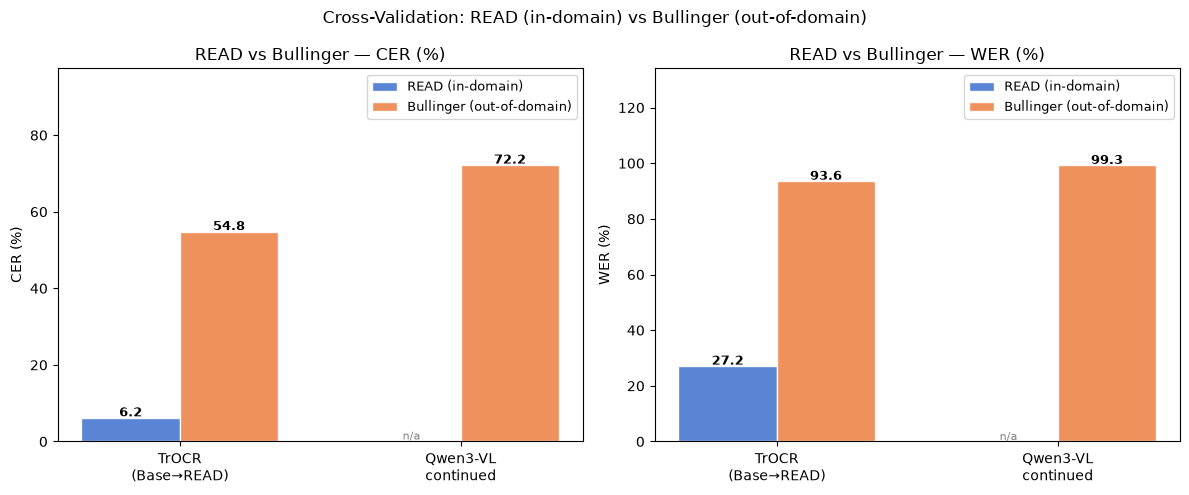

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models    = ["TrOCR\n(Base→READ)", "Qwen3-VL\ncontinued"]
read_cers = [6.18,  None]
bull_cers = [trocr_cer * 100, qwen_ft_cer * 100]
read_wers = [27.24, None]
bull_wers = [trocr_wer * 100, qwen_ft_wer * 100]

x     = np.arange(len(models))
width = 0.35
colors = {"read": "#4878d0", "bull": "#ee854a"}

for ax, (read_vals, bull_vals, metric) in zip(
    axes,
    [(read_cers, bull_cers, "CER (%)"), (read_wers, bull_wers, "WER (%)")],
):
    r_bars = [v if v is not None else 0 for v in read_vals]
    b_bars = bull_vals

    bars_r = ax.bar(x - width / 2, r_bars, width, label="READ (in-domain)",
                    color=colors["read"], edgecolor="white", alpha=0.9)
    bars_b = ax.bar(x + width / 2, b_bars, width, label="Bullinger (out-of-domain)",
                    color=colors["bull"], edgecolor="white", alpha=0.9)

    for bar, val in zip(bars_r, read_vals):
        if val is not None:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                    f"{val:.1f}", ha="center", fontsize=9, fontweight="bold")
        else:
            ax.text(bar.get_x() + bar.get_width() / 2, 0.5,
                    "n/a", ha="center", fontsize=8, color="grey")
    for bar, val in zip(bars_b, bull_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                f"{val:.1f}", ha="center", fontsize=9, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10)
    ax.set_ylabel(metric)
    ax.set_title(f"READ vs Bullinger — {metric}")
    ax.legend(fontsize=9)
    ax.set_ylim(0, max(max(r_bars), max(b_bars)) * 1.35)

plt.suptitle("Cross-Validation: READ (in-domain) vs Bullinger (out-of-domain)", fontsize=12)
plt.tight_layout()
plt.savefig(CKPT_ROOT / "bullinger_crossval.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 8 — Per-line CER Distribution

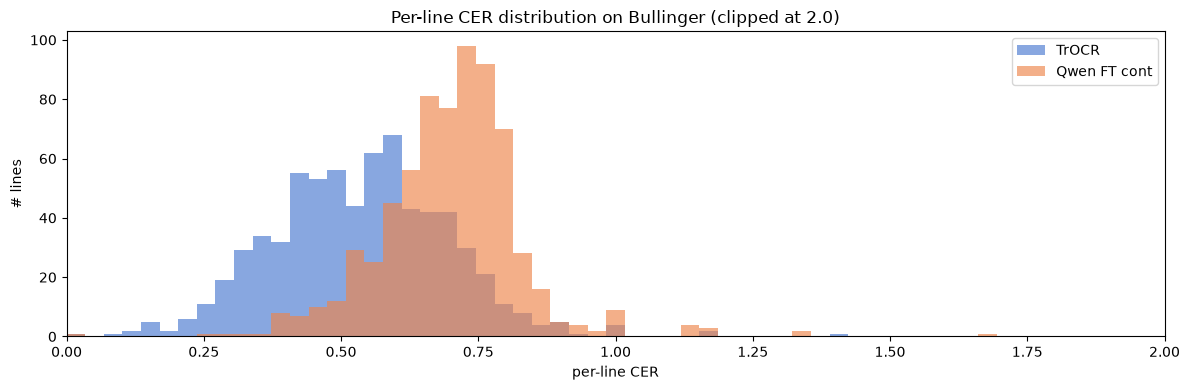

TrOCR           perfect=  1 (0%)  CER<10%=  2 (0%)  median=0.539
Qwen FT cont    perfect=  1 (0%)  CER<10%=  1 (0%)  median=0.708


In [9]:
trocr_line_cers = [line_cer(ref, pred)
                   for ref, pred in zip(trocr_refs, trocr_preds) if ref.strip()]
qft_line_cers   = [line_cer(ref, pred)
                   for ref, pred in zip(qwen_ft_refs, qwen_ft_preds) if ref.strip()]

fig, ax = plt.subplots(figsize=(12, 4))
bins = np.linspace(0, 2, 60)
ax.hist(trocr_line_cers, bins=bins, alpha=0.65, label="TrOCR",       color="#4878d0")
ax.hist(qft_line_cers,   bins=bins, alpha=0.65, label="Qwen FT cont", color="#ee854a")
ax.set_xlabel("per-line CER"); ax.set_ylabel("# lines")
ax.set_title("Per-line CER distribution on Bullinger (clipped at 2.0)")
ax.legend(); ax.set_xlim(0, 2)
plt.tight_layout(); plt.show()

for name, cers in [("TrOCR", trocr_line_cers), ("Qwen FT cont", qft_line_cers)]:
    perfect = sum(c == 0 for c in cers)
    lt10    = sum(c < 0.1 for c in cers)
    print(f"{name:14s}  perfect={perfect:3d} ({perfect/len(cers)*100:.0f}%)  "
          f"CER<10%={lt10:3d} ({lt10/len(cers)*100:.0f}%)  "
          f"median={np.median(cers):.3f}")

## Step 9 — Worst Predictions

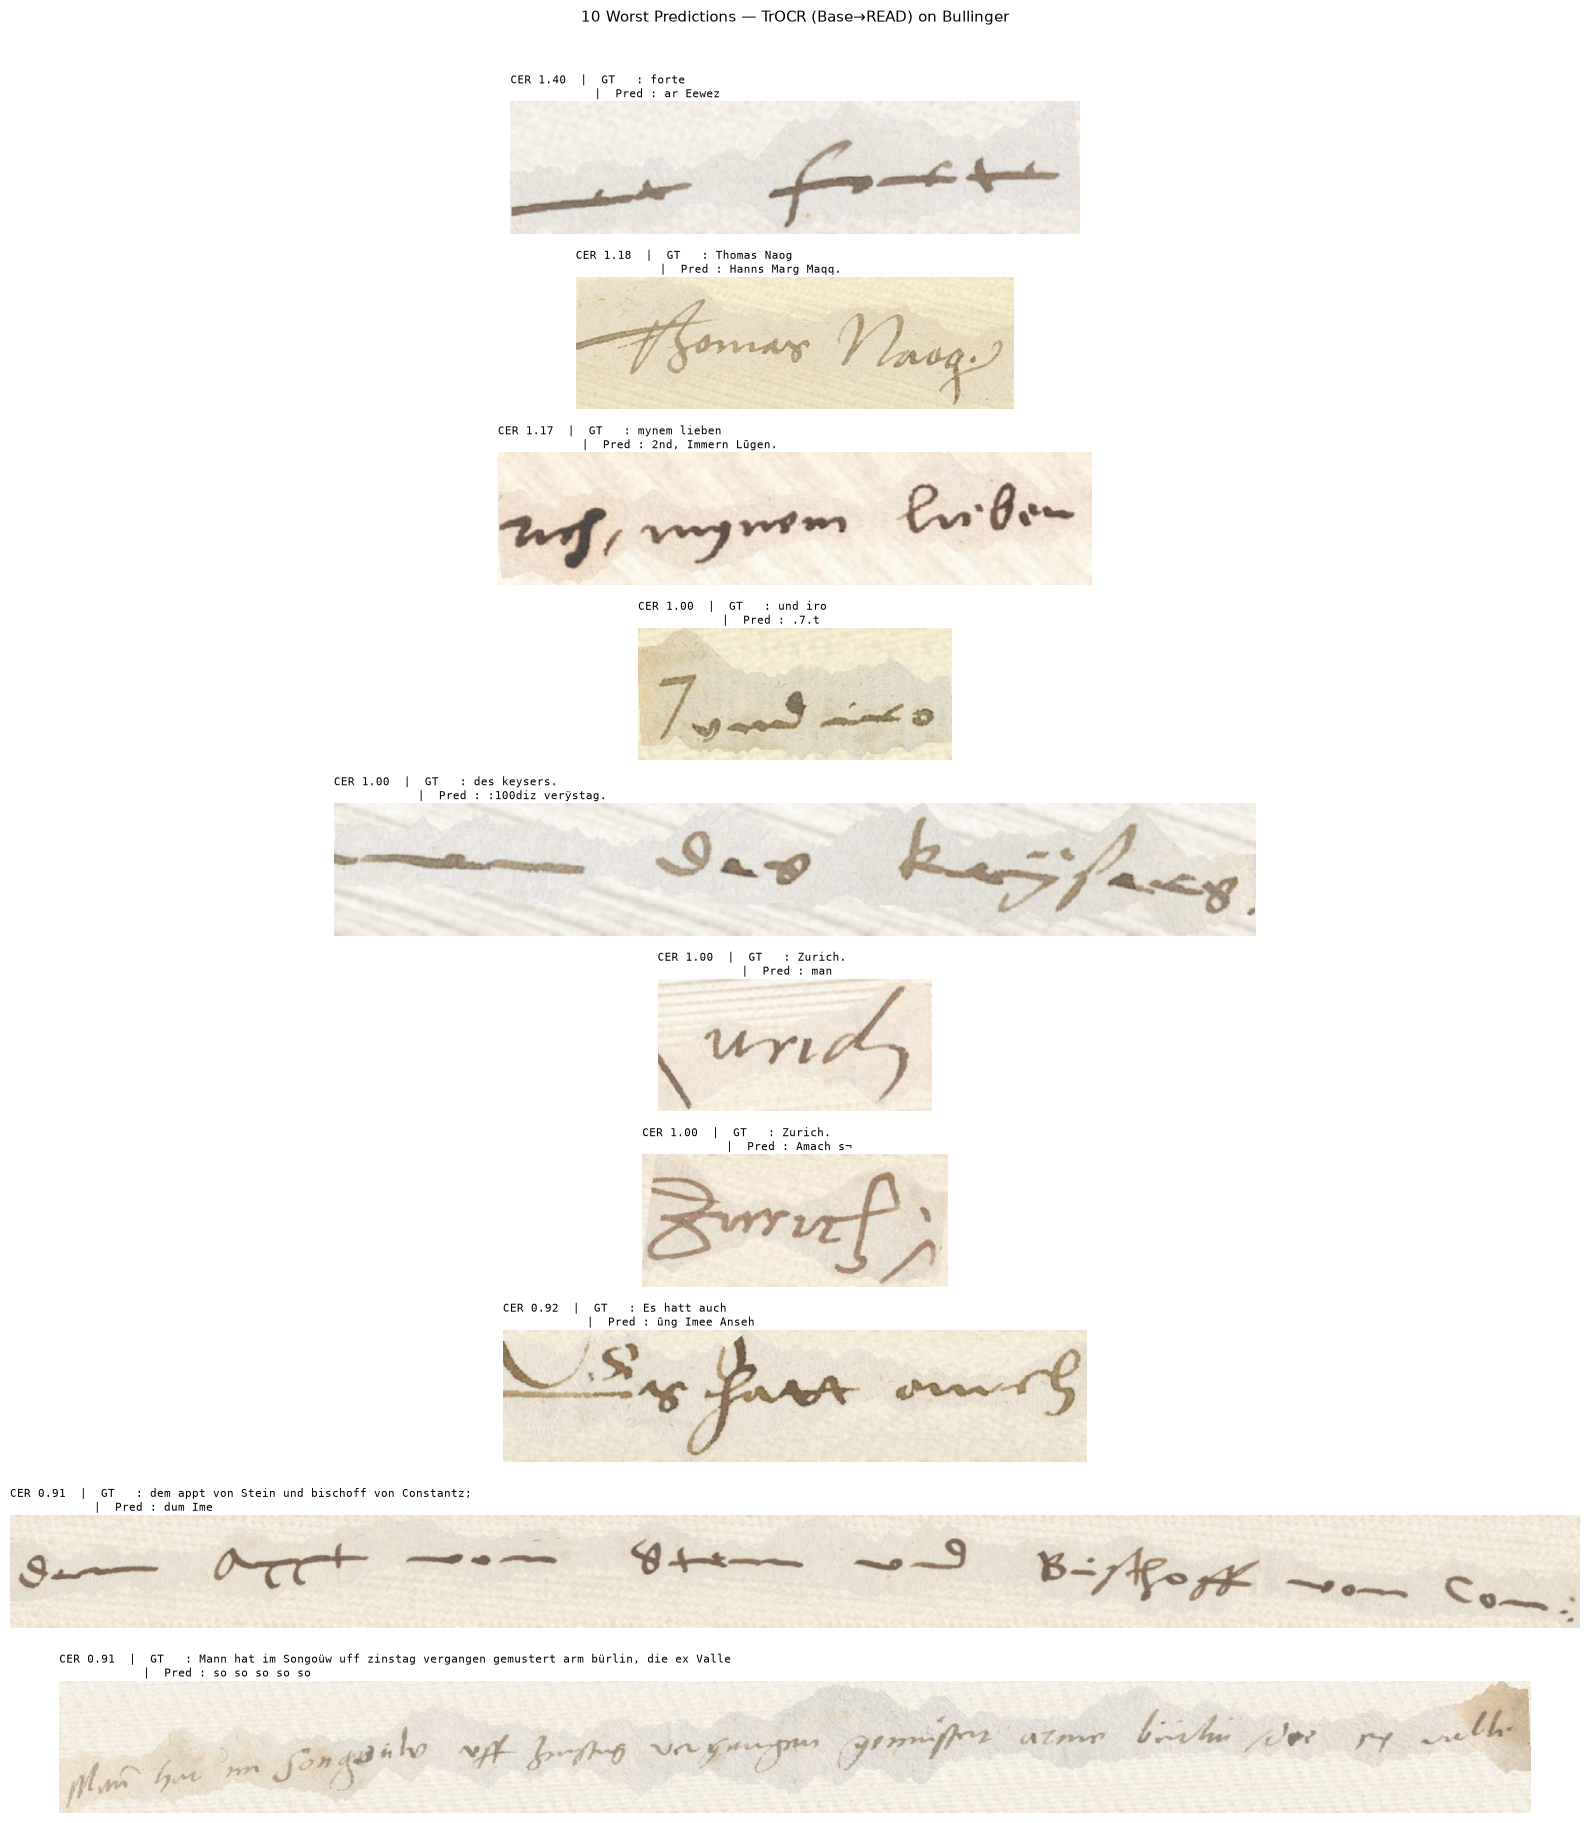

/tmp/ipykernel_6881/1506924410.py:19: UserWarning: Glyph 117 (u) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/home/justin/Ginger_Gradient/14/project/Capstone-Project/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 117 (u) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


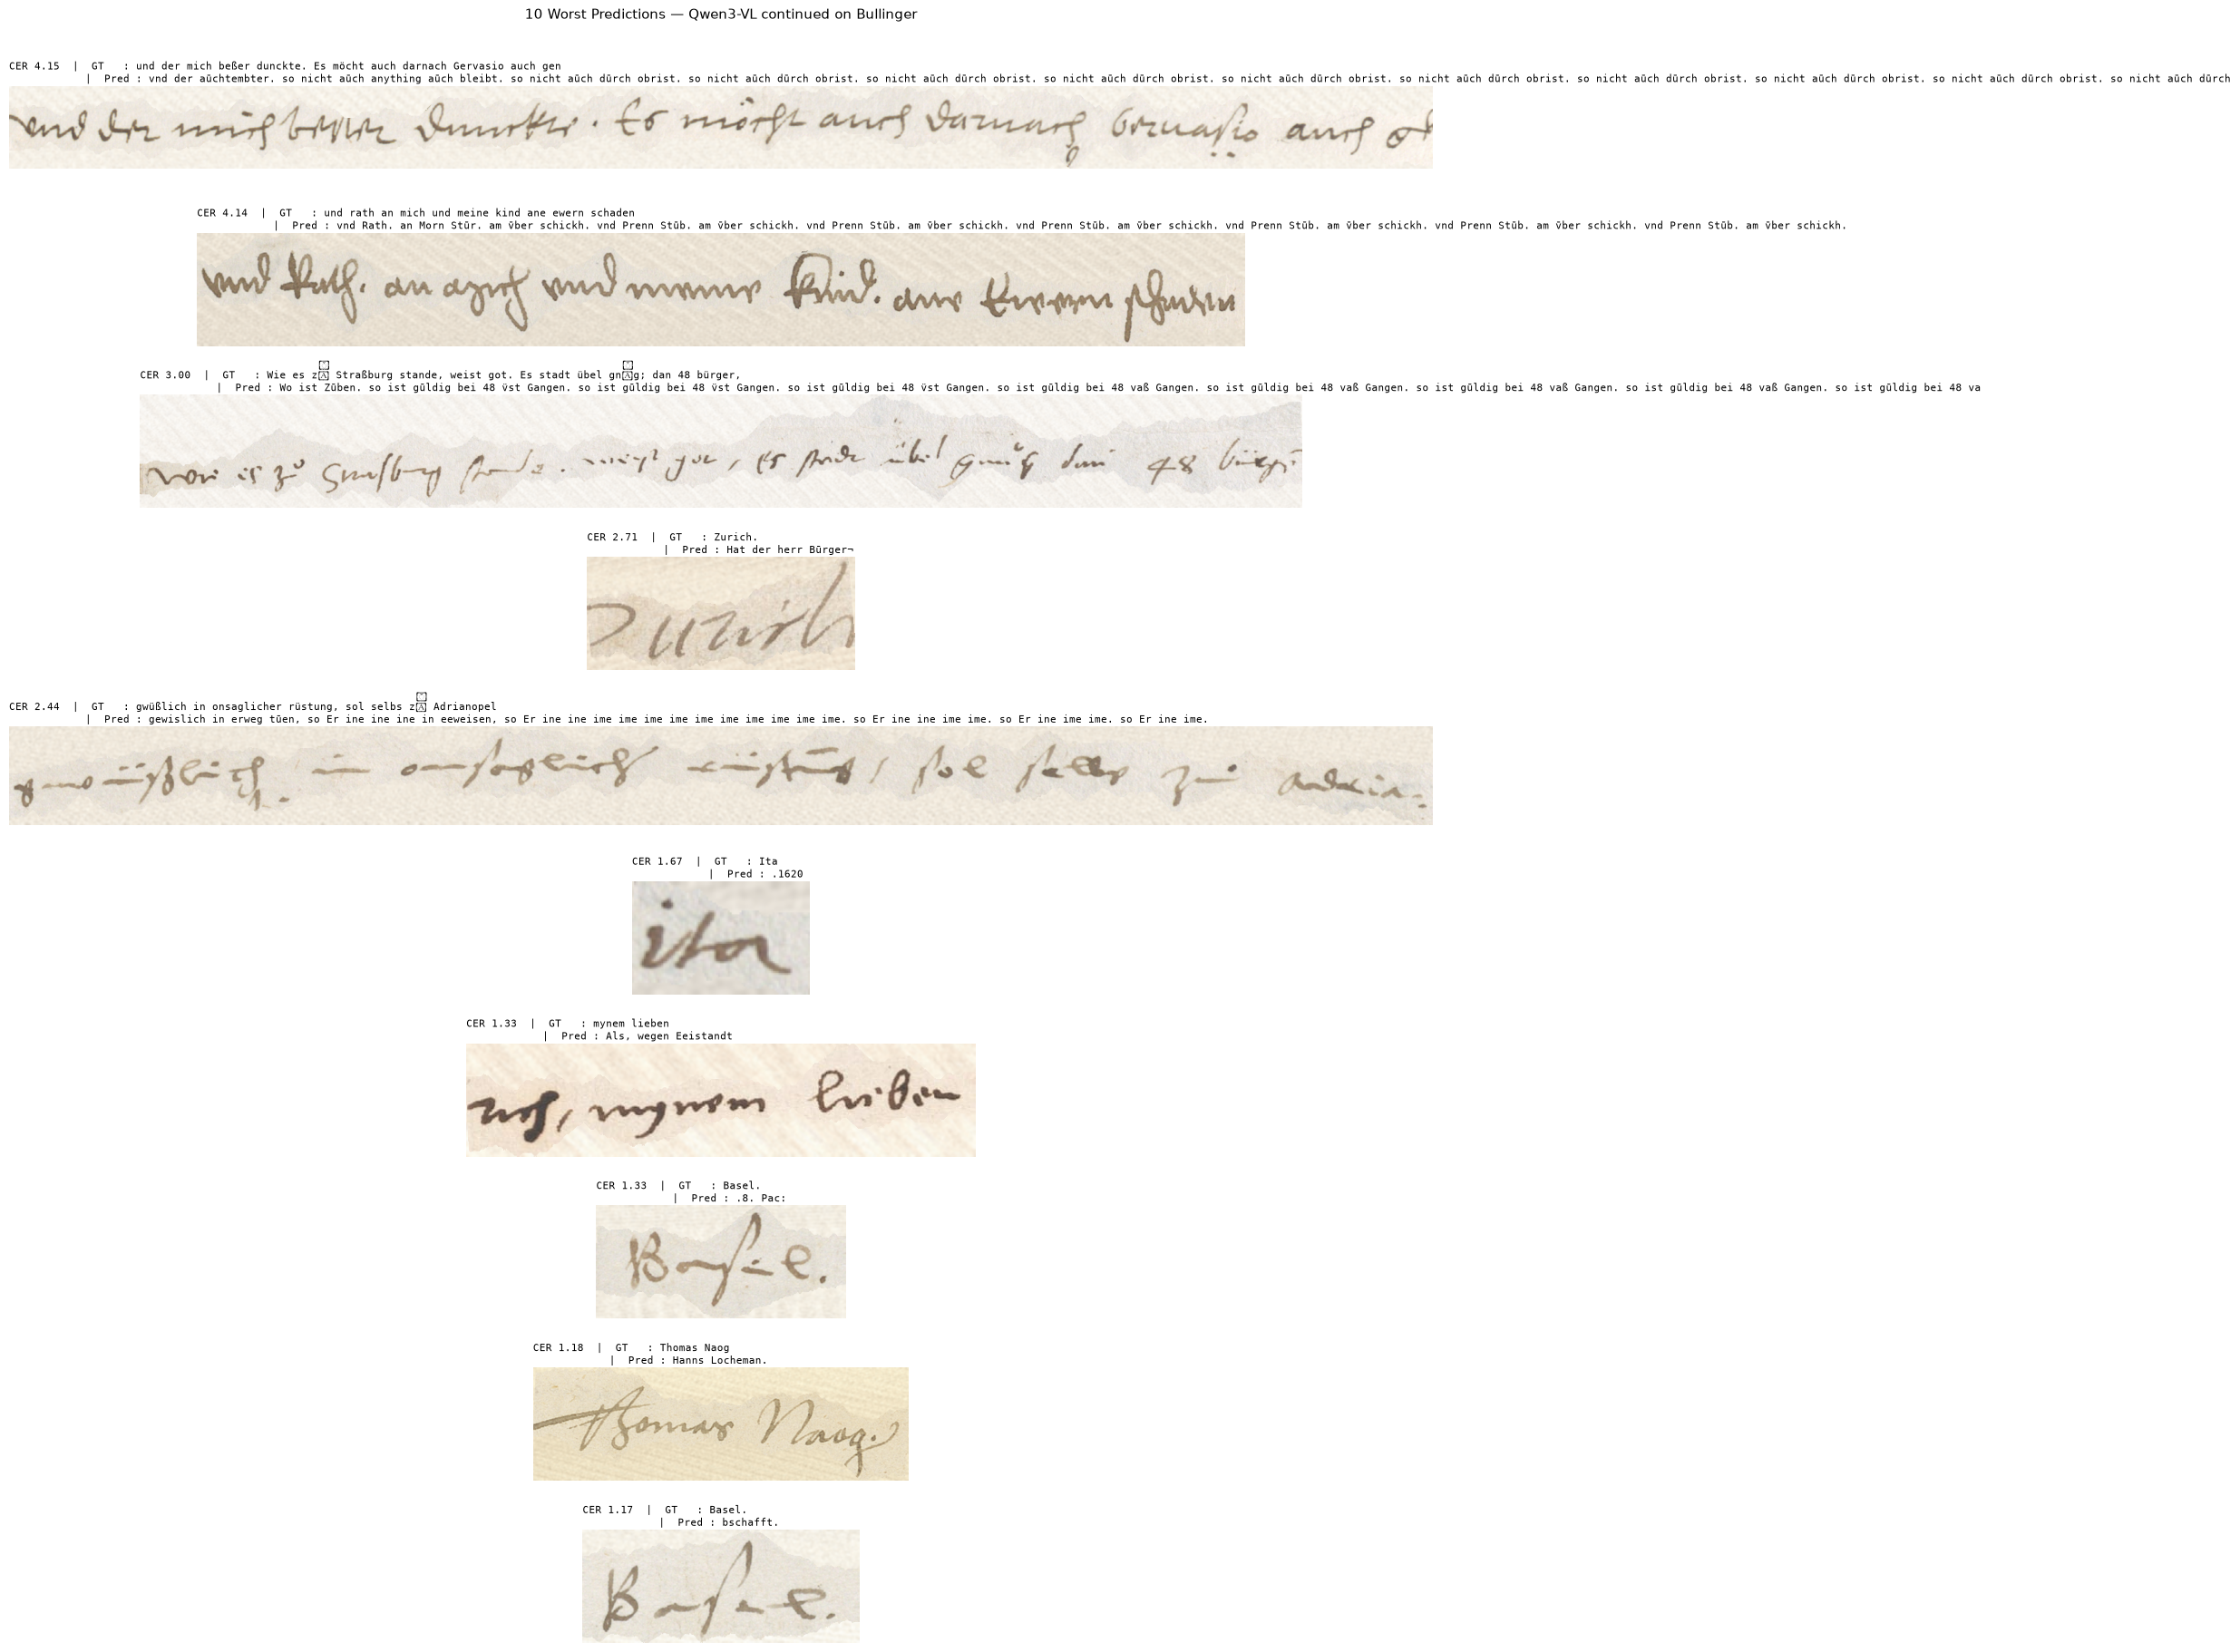

In [10]:
def show_worst(preds, refs, df_data, title, n=10):
    errors = sorted(
        [(line_cer(r, p), i, r, p)
         for i, (r, p) in enumerate(zip(refs, preds)) if r.strip()],
        reverse=True,
    )[:n]

    fig, axes = plt.subplots(n, 1, figsize=(16, n * 1.8))
    for ax, (c, idx, ref, pred) in zip(axes, errors):
        img = Image.open(df_data.iloc[idx]["image_path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(
            f"CER {c:.2f}  |  GT   : {ref}\n"
            f"            |  Pred : {pred}",
            fontsize=8, loc="left", pad=3, family="monospace",
        )
        ax.axis("off")
    plt.suptitle(f"10 Worst Predictions — {title}", fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()


show_worst(trocr_preds,   trocr_refs,   df, "TrOCR (Base→READ) on Bullinger")
show_worst(qwen_ft_preds, qwen_ft_refs, df, "Qwen3-VL continued on Bullinger")

## Step 10 — Side-by-side Comparison (Sample)

In [11]:
sample_idx = df.sample(15, random_state=SEED + 1).index.tolist()

rows_table = []
for idx in sample_idx:
    rows_table.append({
        "GT":           df.loc[idx, "transcription"],
        "TrOCR":        trocr_preds[idx],
        "Qwen FT cont": qwen_ft_preds[idx],
        "TrOCR CER":    round(line_cer(df.loc[idx, "transcription"], trocr_preds[idx]),   3),
        "Qwen FT CER":  round(line_cer(df.loc[idx, "transcription"], qwen_ft_preds[idx]), 3),
    })

df_side = pd.DataFrame(rows_table)
display(df_side)

,GT,TrOCR,Qwen FT cont,TrOCR CER,Qwen FT CER
0,"der kirchen Zürch, mynem",ern der Kirchen vnach vnqugūs,an der vorgede riebs angezaigt,0.667,0.958
1,mitt gar guͦtem,mie gin gūe,mit gar Qūit,0.533,0.400
2,"oder misßfäl, die sich (als wir bericht warenn...","Vir demissar, die fig. as wie gewer wennd, Zeū...","Pitet die sich Zū die berzt werd,",0.542,0.627
3,seckelmeister etc. fand jederman ufrecht und g...,Jeronemsten vnd ist tems Wiehs vn gewww.,Kūebermaister etc. vnd Wār¬,0.661,0.696
4,auch sunst der von Lindow standhaffte antwort ...,"men seist, or von Lūnderstend Pfaffen vnmer ver¬",man mit der Andersteh be¬,0.554,0.750
5,Conradius Roescius; dann es wolt sich nit schi...,Comūder aū g vnd Ir in order vnd vnd Būesstagr...,"Gwerb, das 2000 stār. in.",0.706,0.859
6,"den herrn lieben, und mit allen, qui desiderant","Am herrn Lieben, vnd im Man qui desaver","An herrn Leder, wo nit alle ain Schwa",0.362,0.511
7,hertzen ob dem wort des herrn seyen. Gleicher,"Zerzen, as dem wort des herrn segen, Weilger","heren, ob deme das herrn Būrger¬",0.244,0.511
8,Georg grave zuͦ Würtemberg,Gerry Graūe Zū Wūwmberg,Geen Gmain Zū Notwenders,0.423,0.654
9,gewißlich sein eigen sach ist. Dann ich soll euch,"gerichten, im eigen xxx ist dem ūrs soll em","gezigt, Als ist, in er¬",0.510,0.735
